In [1]:
# ==========================================================
# AI LAW CHAT
# ==========================================================

# ==========================================================
# IMPORT LIBRARY
# ==========================================================

# Data Processing
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

%matplotlib inline

# Text Processing
import re
import string

# File Path
from pathlib import Path

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Display
from IPython.display import display

# Ignore Warning
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ==========================================================
# LOKASI DATASET
# ==========================================================

from pathlib import Path

ROOT_DIR = Path.cwd().parent

DATA_PATH = ROOT_DIR / "data"

KNOWLEDGE_FILE = DATA_PATH / "Knowledge_Base.xlsx"

print(KNOWLEDGE_FILE)
print(KNOWLEDGE_FILE.exists())

/home/claude/eda/verify/data/Knowledge_Base.xlsx
True


In [3]:
# ==========================================================
# LOAD DATASET
# ==========================================================

excel = pd.ExcelFile(KNOWLEDGE_FILE)

regulations = pd.read_excel(excel, sheet_name="Regulations")
articles = pd.read_excel(excel, sheet_name="Articles")
synonyms = pd.read_excel(excel, sheet_name="Synonyms")
faq = pd.read_excel(excel, sheet_name="FAQ (Edukasi Hukum)")
intent = pd.read_excel(excel, sheet_name="Intent")


print("Dataset berhasil dimuat.")

Dataset berhasil dimuat.


In [4]:
# ==========================================================
# CEK UKURAN DATASET
# ==========================================================

print("Regulations :", regulations.shape)

print("Articles :", articles.shape)

print("Synonyms :", synonyms.shape)

print("FAQ :", faq.shape)

print("Intent :", intent.shape)



Regulations : (15, 7)
Articles : (310, 7)
Synonyms : (160, 3)
FAQ : (100, 6)
Intent : (100, 3)


In [5]:
# ==========================================================
# TAMPILKAN DATA
# ==========================================================

display(regulations.head())

display(articles.head())

display(synonyms.head())

display(faq.head())

display(intent.head())

,id_peraturan,nama_peraturan,singkatan,kategori,tahun,deskripsi,sumber
0,1,Kitab Undang-Undang Hukum Pidana,KUHP,Pidana,2023,"Mengatur tindak pidana, jenis pidana, serta pe...",UU No. 1 Tahun 2023
1,2,Kitab Undang-Undang Hukum Perdata,KUHPerdata,Perdata,1848,"Mengatur hubungan hukum antar individu, termas...",KUHPerdata
2,3,Undang-Undang Informasi dan Transaksi Elektronik,UU ITE,Siber,2024,"Mengatur informasi elektronik, transaksi elekt...",UU No. 1 Tahun 2024
3,4,Undang-Undang Perlindungan Konsumen,UUPK,Konsumen,1999,Mengatur hak dan kewajiban konsumen serta pela...,UU No. 8 Tahun 1999
4,5,Undang-Undang Ketenagakerjaan,UUK,Ketenagakerjaan,2003,Mengatur hubungan kerja antara pekerja dan pem...,UU No. 13 Tahun 2003


,id_pasal,id_peraturan,nama_peraturan,pasal,topik,isi_singkat,kata_kunci
0,1,1,KUHP,Pasal 362,Pencurian,Mengatur tindak pidana mengambil barang milik ...,"pencurian, mencuri, mengambil barang"
1,2,1,KUHP,Pasal 363,Pencurian dengan Pemberatan,Mengatur pencurian dengan keadaan tertentu yan...,"pencurian berat, pembobolan"
2,3,1,KUHP,Pasal 364,Pencurian Ringan,Mengatur pencurian dengan nilai kerugian terte...,pencurian ringan
3,4,1,KUHP,Pasal 365,Pencurian dengan Kekerasan,Mengatur pencurian yang disertai kekerasan ata...,"perampokan, begal"
4,5,1,KUHP,Pasal 372,Penggelapan,Mengatur perbuatan menguasai barang milik oran...,penggelapan


,id,kata_asli,sinonim
0,1,pencurian,mencuri
1,2,pencurian,nyuri
2,3,pencurian,nyolong
3,4,pencurian,ambil barang
4,5,penipuan,menipu


,id,id_peraturan,nama_peraturan,intent,pertanyaan,jawaban
0,1,1,KUHP,Definisi,Apa itu tindak pidana?,Tindak pidana adalah perbuatan yang dilarang o...
1,2,1,KUHP,Definisi,Apa itu kejahatan?,Kejahatan adalah perbuatan yang melanggar huku...
2,3,1,KUHP,Pencurian,Apa yang dimaksud pencurian?,Pencurian adalah mengambil barang milik orang ...
3,4,1,KUHP,Pencurian,Apa hukuman pencurian?,Ancaman pidana pencurian diatur dalam KUHP dan...
4,5,1,KUHP,Penipuan,Apa itu penipuan?,Penipuan adalah memperoleh keuntungan dengan m...


,id,intent,contoh_kalimat
0,1,Definisi,Apa itu tindak pidana?
1,2,Definisi,Apa yang dimaksud hukum perdata?
2,3,Definisi,Apa itu UU ITE?
3,4,Definisi,Apa arti hak cipta?
4,5,Definisi,Apa yang dimaksud narkotika?


In [6]:
# ==========================================================
# VALIDASI DATASET
# ==========================================================

print("Missing Value")

print()

print(regulations.isnull().sum())

print()

print(articles.isnull().sum())

print()

print(synonyms.isnull().sum())

print()

print(faq.isnull().sum())

print()

print(intent.isnull().sum())

print()



Missing Value

id_peraturan      0
nama_peraturan    0
singkatan         0
kategori          0
tahun             0
deskripsi         0
sumber            0
dtype: int64

id_pasal          0
id_peraturan      0
nama_peraturan    0
pasal             0
topik             0
isi_singkat       0
kata_kunci        0
dtype: int64

id           0
kata_asli    0
sinonim      0
dtype: int64

id                0
id_peraturan      0
nama_peraturan    0
intent            0
pertanyaan        0
jawaban           0
dtype: int64

id                0
intent            0
contoh_kalimat    0
dtype: int64



In [7]:
# ==========================================================
# DUPLICATE CHECK
# ==========================================================

print("Duplicate Regulations")

print(regulations.duplicated().sum())

print()

print("Duplicate Articles")

print(articles.duplicated().sum())

print()

print("Duplicate Synonyms")

print(synonyms.duplicated().sum())

print()

print("Duplicate FAQ")

print(faq.duplicated().sum())

print()

print("Duplicate Intent")

print(intent.duplicated().sum())

print()





Duplicate Regulations
0

Duplicate Articles
0

Duplicate Synonyms
0

Duplicate FAQ
0

Duplicate Intent
0



## 4. Exploratory Data Analysis (EDA)

Tahap ini bertujuan memahami karakteristik dan pola dalam basis pengetahuan (*knowledge base*) sebelum masuk ke tahap *data preparation* dan *modeling*. Karena data yang digunakan bersifat tekstual/kategorikal (bukan data numerik), visualisasi difokuskan pada distribusi kategori, distribusi panjang teks, komposisi label, serta keterkaitan antar kategori.

In [8]:
# ==========================================================
# IMPORT LIBRARY VISUALISASI
# ==========================================================

import seaborn as sns
from collections import Counter

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
PALETTE = "crest"

### 4.1 Distribusi Jumlah Pasal per Peraturan (Bar Chart)

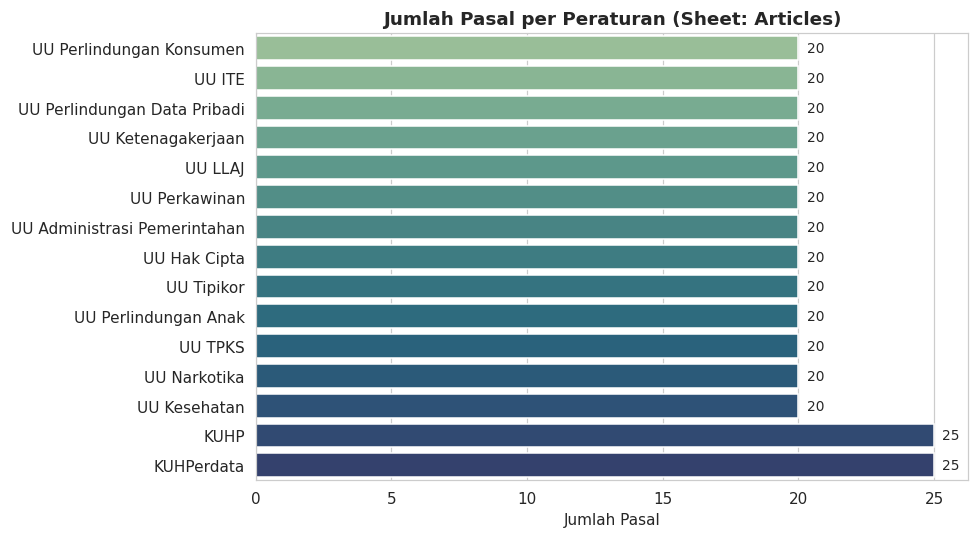

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

counts = articles["nama_peraturan"].value_counts().sort_values()

sns.barplot(x=counts.values, y=counts.index, hue=counts.index, palette=PALETTE, legend=False, ax=ax)

ax.set_title("Jumlah Pasal per Peraturan (Sheet: Articles)", fontweight="bold")
ax.set_xlabel("Jumlah Pasal")
ax.set_ylabel("")

for i, v in enumerate(counts.values):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.show()

### 4.2 Proporsi Kategori Peraturan (Pie Chart)

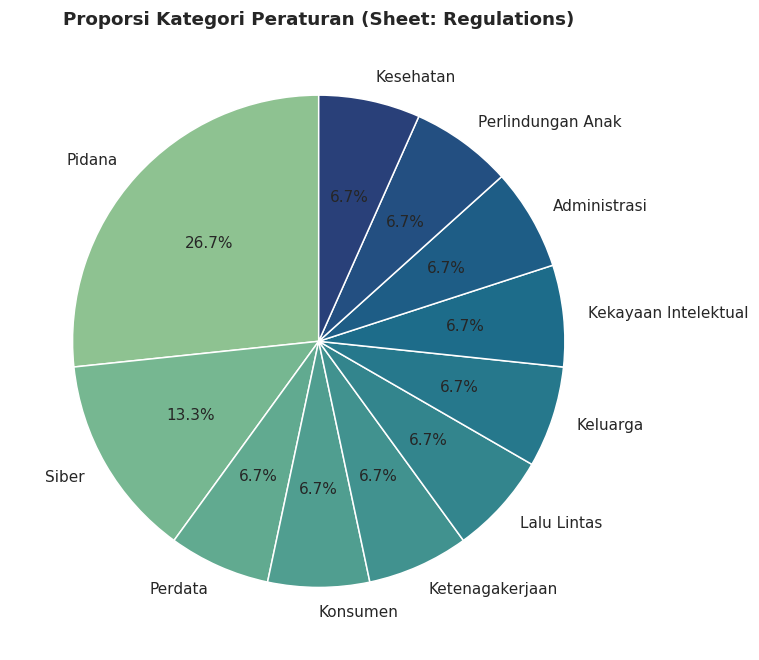

In [10]:
fig, ax = plt.subplots(figsize=(7, 7))

kat = regulations["kategori"].value_counts()
colors = sns.color_palette(PALETTE, len(kat))

ax.pie(kat.values, labels=kat.index, autopct="%1.1f%%", colors=colors,
       startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1})

ax.set_title("Proporsi Kategori Peraturan (Sheet: Regulations)", fontweight="bold")

plt.tight_layout()
plt.show()

### 4.3 Distribusi Label Intent pada Data Latih (Bar Chart & Deteksi Imbalanced Class)

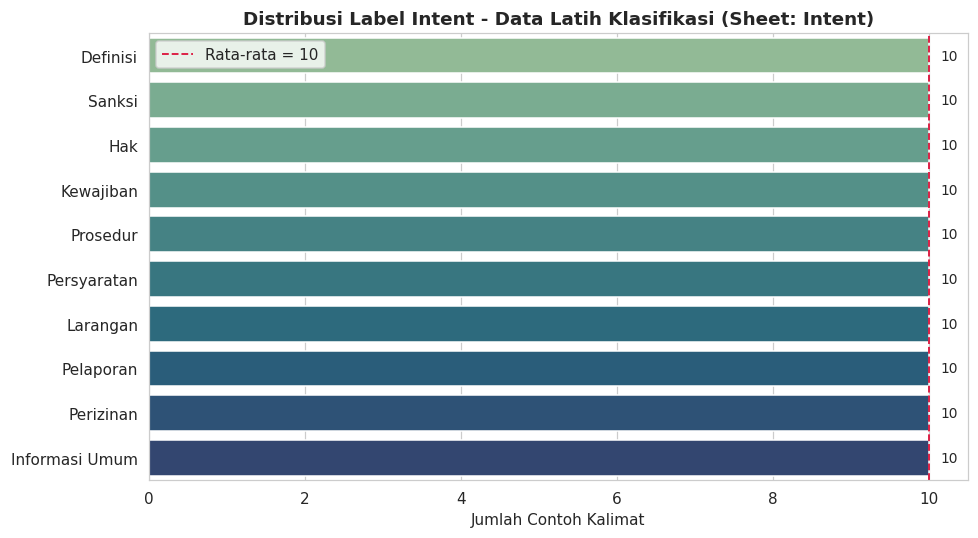

Standar deviasi jumlah contoh antar kelas intent: 0.0
Kesimpulan: seluruh kelas memiliki jumlah contoh yang SAMA (10 per kelas),
artinya data latih intent TIDAK mengalami class imbalance, namun jumlah
contoh per kelas tergolong sangat sedikit (hanya 10), sehingga model rawan
mengalami underfitting/generalisasi buruk pada pola kalimat baru.


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

ic = intent["intent"].value_counts().sort_values()

sns.barplot(x=ic.values, y=ic.index, hue=ic.index, palette=PALETTE, legend=False, ax=ax)

ax.set_title("Distribusi Label Intent - Data Latih Klasifikasi (Sheet: Intent)", fontweight="bold")
ax.set_xlabel("Jumlah Contoh Kalimat")
ax.set_ylabel("")
ax.axvline(ic.mean(), color="crimson", linestyle="--", linewidth=1.2, label=f"Rata-rata = {ic.mean():.0f}")

for i, v in enumerate(ic.values):
    ax.text(v + 0.15, i, str(v), va="center", fontsize=9)

ax.legend()
plt.tight_layout()
plt.show()

print("Standar deviasi jumlah contoh antar kelas intent:", ic.std())
print("Kesimpulan: seluruh kelas memiliki jumlah contoh yang SAMA (10 per kelas),")
print("artinya data latih intent TIDAK mengalami class imbalance, namun jumlah")
print("contoh per kelas tergolong sangat sedikit (hanya 10), sehingga model rawan")
print("mengalami underfitting/generalisasi buruk pada pola kalimat baru.")

### 4.4 Distribusi Panjang Kalimat (Histogram)

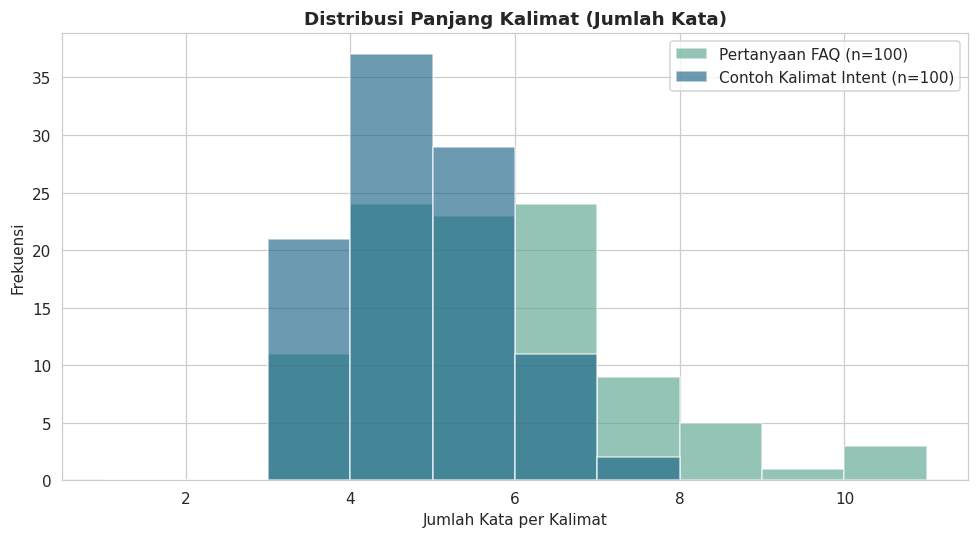

Rata-rata panjang pertanyaan FAQ : 5.30 kata (min=3, max=10)
Rata-rata panjang kalimat Intent : 4.36 kata (min=3, max=7)


In [12]:
def word_count(s):
    return len(str(s).split())

faq_len = faq["pertanyaan"].apply(word_count)
intent_len = intent["contoh_kalimat"].apply(word_count)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(faq_len, bins=range(1, faq_len.max() + 2), alpha=0.65,
        label=f"Pertanyaan FAQ (n={len(faq_len)})", color=sns.color_palette(PALETTE)[1])
ax.hist(intent_len, bins=range(1, intent_len.max() + 2), alpha=0.65,
        label=f"Contoh Kalimat Intent (n={len(intent_len)})", color=sns.color_palette(PALETTE)[4])

ax.set_title("Distribusi Panjang Kalimat (Jumlah Kata)", fontweight="bold")
ax.set_xlabel("Jumlah Kata per Kalimat")
ax.set_ylabel("Frekuensi")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Rata-rata panjang pertanyaan FAQ : {faq_len.mean():.2f} kata (min={faq_len.min()}, max={faq_len.max()})")
print(f"Rata-rata panjang kalimat Intent : {intent_len.mean():.2f} kata (min={intent_len.min()}, max={intent_len.max()})")

### 4.5 Korelasi Antar Fitur: Heatmap Kategori Peraturan x Intent

Karena dataset bersifat kategorikal (bukan numerik), analisis korelasi diadaptasi menjadi **heatmap crosstab** antara kategori peraturan dan label intent pada sheet FAQ. Ini menunjukkan keterkaitan/pola kemunculan intent tertentu pada kategori hukum tertentu.

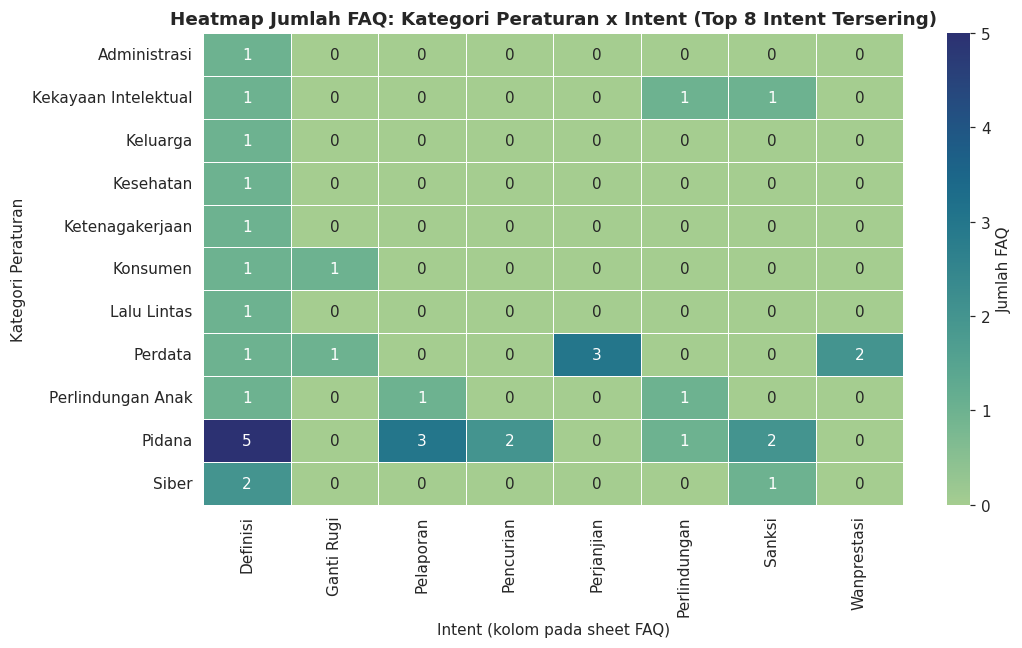

In [13]:
faq_merged = faq.merge(regulations[["id_peraturan", "kategori"]], on="id_peraturan", how="left")

top_intents = faq["intent"].value_counts().head(8).index
sub = faq_merged[faq_merged["intent"].isin(top_intents)]

cross = pd.crosstab(sub["kategori"], sub["intent"])

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(cross, annot=True, fmt="d", cmap="crest", linewidths=0.5,
            cbar_kws={"label": "Jumlah FAQ"}, ax=ax)

ax.set_title("Heatmap Jumlah FAQ: Kategori Peraturan x Intent (Top 8 Intent Tersering)", fontweight="bold")
ax.set_xlabel("Intent (kolom pada sheet FAQ)")
ax.set_ylabel("Kategori Peraturan")

plt.tight_layout()
plt.show()

### 4.6 Kata Kunci Pasal yang Paling Sering Muncul (Bar Chart)

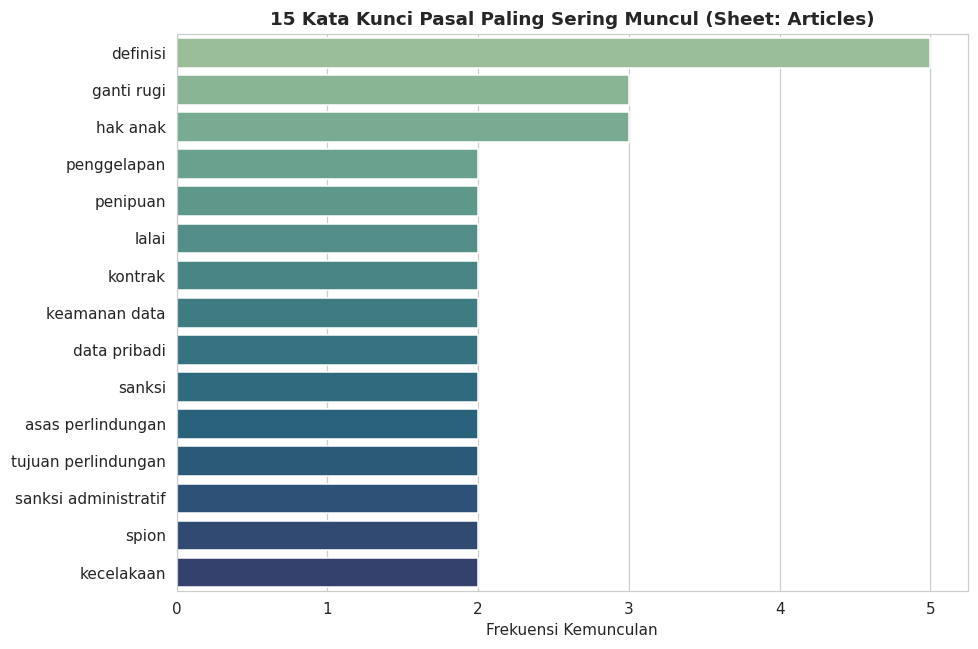

In [14]:
all_keywords = []
for kw in articles["kata_kunci"].dropna():
    parts = [p.strip().lower() for p in str(kw).split(",")]
    all_keywords.extend(parts)

freq = Counter(all_keywords).most_common(15)
words, vals = zip(*freq)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=list(vals), y=list(words), hue=list(words), palette=PALETTE, legend=False, ax=ax)

ax.set_title("15 Kata Kunci Pasal Paling Sering Muncul (Sheet: Articles)", fontweight="bold")
ax.set_xlabel("Frekuensi Kemunculan")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### 4.7 Insight Awal dari EDA

Berdasarkan visualisasi di atas, diperoleh beberapa insight awal:

1. **Cakupan pasal cukup merata**, kecuali KUHP dan KUHPerdata yang memiliki jumlah pasal lebih banyak (25) dibanding 13 peraturan lain (masing-masing 20 pasal) — wajar karena keduanya adalah kitab hukum utama dengan cakupan topik terluas.
2. **Kategori peraturan didominasi kategori Pidana** (4 dari 15 peraturan), sedangkan 9 kategori lain (Perdata, Konsumen, Ketenagakerjaan, dll.) masing-masing hanya diwakili 1 peraturan — mencerminkan fokus knowledge base pada topik pidana/kejahatan sehari-hari yang paling sering ditanyakan masyarakat awam.
3. **Data latih Intent (100 contoh) justru seimbang** — setiap 10 kelas intent memiliki tepat 10 contoh kalimat (standar deviasi = 0). Artinya masalah akurasi 73,33% pada bagian Evaluation **bukan disebabkan oleh class imbalance**, melainkan oleh **jumlah data latih yang terlalu sedikit per kelas** untuk menangkap variasi pola kalimat bahasa Indonesia.
4. **Kalimat pengguna umumnya pendek** (rata-rata 4-5 kata), sehingga fitur teks yang tersedia bagi model klasifikasi relatif terbatas — ini menjelaskan mengapa kalimat tanpa istilah hukum eksplisit (yang tidak ter-*masking* menjadi `<HUKUM>`) sulit diklasifikasikan dengan benar.
5. **Heatmap kategori x intent** menunjukkan intent "Definisi" tersebar merata di hampir semua kategori peraturan, sedangkan intent yang lebih spesifik (mis. terkait sanksi/pelaporan) cenderung terkonsentrasi pada kategori tertentu (Pidana, Siber) — pola ini konsisten dengan sifat topik hukum masing-masing kategori.
6. **Kata kunci pasal paling sering** didominasi istilah umum seperti "definisi", "ganti rugi", dan "hak anak", menunjukkan knowledge base cukup menekankan aspek definisi dan hak/kewajiban dasar dibanding istilah prosedural yang lebih teknis.

In [15]:
# ==========================================================
# PREPROCESSOR
# ==========================================================

class TextPreprocessor:

    def __init__(self):
        pass

    def clean(self,text):

        if pd.isna(text):
            return ""

        text = str(text)

        text = text.lower()

        text = re.sub(r"http\S+"," ",text)

        text = re.sub(r"<.*?>"," ",text)

        text = re.sub(r"\d+"," ",text)

        text = text.translate(
            str.maketrans("","",string.punctuation)
        )

        text = re.sub(r"\s+"," ",text)

        return text.strip()

In [16]:
preprocessor = TextPreprocessor()

kalimat = "Apa HUKUMAN bagi orang yang NYOLONG motor???"

hasil = preprocessor.clean(kalimat)

print(hasil)

apa hukuman bagi orang yang nyolong motor


In [17]:
# ==========================================================
# SYNONYM ENGINE
# ==========================================================

import re

class SynonymEngine:

    def __init__(self, dataframe):

        self.synonym_dict = {}

        for _, row in dataframe.iterrows():

            kata_asli = str(
                row["kata_asli"]
            ).strip().lower()

            sinonim = str(
                row["sinonim"]
            ).strip().lower()

            if kata_asli and sinonim:

                self.synonym_dict[sinonim] = kata_asli

    def normalize(self, text):

        hasil = text.lower()

        for sinonim, kata_asli in self.synonym_dict.items():

            pattern = r"\b" + re.escape(sinonim) + r"\b"

            hasil = re.sub(
                pattern,
                kata_asli,
                hasil
            )

        return hasil

In [18]:
engine = SynonymEngine(synonyms)

kalimat = "Apa HUKUMAN bagi orang yang NYOLONG motor???"

kalimat = preprocessor.clean(kalimat)

hasil = engine.normalize(kalimat)

print(hasil)

apa hukuman bagi orang yang pencurian motor


In [19]:
contoh = [

    "apa itu wanprestasi",

    "bagaimana cara mengajukan gugatan perdata",

    "apa sanksi pencemaran nama baik",

    "bagaimana prosedur perceraian",

    "apa hak pekerja yang di phk"

]

for text in contoh:

    clean = preprocessor.clean(text)

    hasil = engine.normalize(clean)

    print("---------------------------")

    print("Input :", text)

    print("Output:", hasil)

---------------------------
Input : apa itu wanprestasi
Output: apa itu wanprestasi
---------------------------
Input : bagaimana cara mengajukan gugatan perdata
Output: bagaimana cara mengajukan gugatan perdata
---------------------------
Input : apa sanksi pencemaran nama baik
Output: apa sanksi pencemaran nama baik
---------------------------
Input : bagaimana prosedur perceraian
Output: bagaimana prosedur perceraian
---------------------------
Input : apa hak pekerja yang di phk
Output: apa hak pekerja yang di phk


In [20]:
# ==========================================================
# MEMBUAT LEGAL DICTIONARY
# ==========================================================

LEGAL_DICT = {}

# ==========================================================
# REGULATIONS
# ==========================================================

for _, row in regulations.iterrows():

    nama = str(row["nama_peraturan"]).strip()

    # Nama lengkap
    LEGAL_DICT[
        preprocessor.clean(nama)
    ] = nama

    # Singkatan
    if pd.notna(row["singkatan"]):

        LEGAL_DICT[
            preprocessor.clean(str(row["singkatan"]))
        ] = nama

    # Nama umum
    nama_lower = nama.lower()

    if "kitab undang-undang hukum " in nama_lower:

        umum = nama_lower.replace(
            "kitab undang-undang hukum ",
            ""
        )

        LEGAL_DICT[
            preprocessor.clean("hukum " + umum)
        ] = nama

# ==========================================================
# CETAK
# ==========================================================

print("Jumlah legal :", len(LEGAL_DICT))

Jumlah legal : 32


In [21]:
mapping = dict(
    zip(
        regulations["singkatan"],
        regulations["nama_peraturan"]
    )
)

articles["nama_peraturan"] = (
    articles["nama_peraturan"]
    .replace(mapping)
)

In [22]:
# ==========================================================
# MEMBUAT LEGAL ALIAS
# ==========================================================

LEGAL_ALIAS = {}

# ----------------------------------------------------------
# 1. Alias dari sheet Synonyms
# ----------------------------------------------------------
for _, row in synonyms.iterrows():

    LEGAL_ALIAS[
        preprocessor.clean(str(row["sinonim"]))
    ] = row["kata_asli"]

# ----------------------------------------------------------
# 2. Alias dari singkatan peraturan
# ----------------------------------------------------------
for _, row in regulations.iterrows():

    if pd.notna(row["singkatan"]):

        LEGAL_ALIAS[
            preprocessor.clean(str(row["singkatan"]))
        ] = row["nama_peraturan"]

# ----------------------------------------------------------
# 3. Alias dari TOPIK
# ----------------------------------------------------------
for _, row in articles.iterrows():

    if pd.notna(row["topik"]):

        LEGAL_ALIAS[
            preprocessor.clean(str(row["topik"]))
        ] = row["nama_peraturan"]

# ----------------------------------------------------------
# 4. Alias dari KATA KUNCI
# ----------------------------------------------------------
for _, row in articles.iterrows():

    if pd.notna(row["kata_kunci"]):

        for keyword in str(row["kata_kunci"]).split(","):

            keyword = preprocessor.clean(keyword.strip())

            if keyword != "":

                LEGAL_ALIAS[keyword] = row["nama_peraturan"]

print("Jumlah alias :", len(LEGAL_ALIAS))
print("Alias pencurian :", LEGAL_ALIAS.get("pencurian"))
print("Alias mencuri :", LEGAL_ALIAS.get("mencuri"))

Jumlah alias : 694
Alias pencurian : Kitab Undang-Undang Hukum Pidana
Alias mencuri : Kitab Undang-Undang Hukum Pidana


In [23]:
print(LEGAL_ALIAS["pencurian"])
print(LEGAL_ALIAS["mencuri"])
print(LEGAL_ALIAS["penipuan"])

Kitab Undang-Undang Hukum Pidana
Kitab Undang-Undang Hukum Pidana
Kitab Undang-Undang Hukum Perdata


In [24]:
# ==========================================================
# LEGAL RECOGNIZER
# ==========================================================

import re

class LegalRecognizer:

    def __init__(
        self,
        legal_dict,
        alias,
        preprocessor
    ):

        self.legal_dict = legal_dict
        self.alias = alias
        self.preprocessor = preprocessor

    def predict(self, text):

        text = self.preprocessor.clean(text)

        # =========================
        # Alias
        # =========================
        for key, value in self.alias.items():

            pattern = r"\b" + re.escape(key) + r"\b"

            if re.search(pattern, text):

                return value

        # =========================
        # Cari semua kandidat
        # =========================
        candidates = []

        for key, value in self.legal_dict.items():

            pattern = r"\b" + re.escape(key) + r"\b"

            if re.search(pattern, text):

                candidates.append((len(key), value))

        if not candidates:

            return None

        # Ambil istilah yang paling panjang
        candidates.sort(key=lambda x: x[0], reverse=True)

        return candidates[0][1]

In [25]:
# ==========================================================
# MEMBUAT OBJECT
# ==========================================================

legal_ai = LegalRecognizer(

    LEGAL_DICT,

    LEGAL_ALIAS,

    preprocessor

)

In [26]:
hasil = legal_ai.predict(

    "Apa HUKUMAN bagi orang yang NYOLONG motor???"

)

print(hasil)

pencurian


In [27]:
contoh = [

    "Apa HUKUMAN bagi orang yang NYOLONG motor???",

    "Bagaimana prosedur perceraian?"


]

for text in contoh:

    hasil = legal_ai.predict(text)

    print("="*50)

    print("INPUT :", text)

    print("HASIL :", hasil)

INPUT : Apa HUKUMAN bagi orang yang NYOLONG motor???
HASIL : pencurian
INPUT : Bagaimana prosedur perceraian?
HASIL : Undang-Undang Perkawinan


In [28]:
# ==========================================================
# CEK APAKAH USER MENYEBUTKAN ISTILAH HUKUM
# ==========================================================

def contains_legal(text):

    legal = legal_ai.predict(text)

    if legal is None:

        return False

    return True

In [29]:
print(

    contains_legal(

        "Apa HUKUMAN bagi orang yang NYOLONG motor???"

    )

)

True


In [30]:
# ==========================================================
# MENYIAPKAN DATA INTENT
# ==========================================================

intent_df = intent.copy()

intent_df.head()

,id,intent,contoh_kalimat
0,1,Definisi,Apa itu tindak pidana?
1,2,Definisi,Apa yang dimaksud hukum perdata?
2,3,Definisi,Apa itu UU ITE?
3,4,Definisi,Apa arti hak cipta?
4,5,Definisi,Apa yang dimaksud narkotika?


In [31]:
# ==========================================================
# PREPROCESSING DATA INTENT
# ==========================================================

import re

intent_df["clean_text"] = intent_df["contoh_kalimat"].apply(
    preprocessor.clean
)

for i, row in intent_df.iterrows():

    text = row["clean_text"]

    # Alias
    for key in LEGAL_ALIAS.keys():

        pattern = r"\b" + re.escape(key) + r"\b"

        text = re.sub(
            pattern,
            "<HUKUM>",
            text
        )

    # Istilah hukum
    for key in LEGAL_DICT.keys():

        pattern = r"\b" + re.escape(key) + r"\b"

        text = re.sub(
            pattern,
            "<HUKUM>",
            text
        )

    intent_df.at[i, "clean_text"] = text

intent_df.head()

,id,intent,contoh_kalimat,clean_text
0,1,Definisi,Apa itu tindak pidana?,apa itu tindak <HUKUM>
1,2,Definisi,Apa yang dimaksud hukum perdata?,apa yang dimaksud <HUKUM>
2,3,Definisi,Apa itu UU ITE?,apa itu <HUKUM>
3,4,Definisi,Apa arti hak cipta?,apa arti <HUKUM>
4,5,Definisi,Apa yang dimaksud narkotika?,apa yang dimaksud <HUKUM>


In [32]:
# ==========================================================
# TF-IDF VECTORIZER
# ==========================================================

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_intent = vectorizer.fit_transform(
    intent_df["clean_text"]
)

In [33]:
# ==========================================================
# LABEL INTENT
# ==========================================================

y_intent = intent_df["intent"]

In [34]:
# ==========================================================
# MODEL INTENT
# ==========================================================

from sklearn.linear_model import LogisticRegression

intent_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

intent_model.fit(
    X_intent,
    y_intent
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [35]:
# ==========================================================
# INTENT RECOGNIZER
# ==========================================================

class IntentRecognizer:

    def __init__(
        self,
        model,
        vectorizer,
        preprocessor,
        legal_recognizer
    ):

        self.model = model
        self.vectorizer = vectorizer
        self.preprocessor = preprocessor
        self.legal_recognizer = legal_recognizer


    def normalize_input(self, text):

        clean_text = self.preprocessor.clean(text)

        # Alias
        for key in self.legal_recognizer.alias.keys():

            pattern = r"\b" + re.escape(key) + r"\b"

            clean_text = re.sub(
                pattern,
                "<HUKUM>",
                clean_text
            )

        # Legal dictionary
        for key in self.legal_recognizer.legal_dict.keys():

            pattern = r"\b" + re.escape(key) + r"\b"

            clean_text = re.sub(
                pattern,
                "<HUKUM>",
                clean_text
            )

        return clean_text


    def predict(self, text):

        normalized = self.normalize_input(text)

        vector = self.vectorizer.transform(
            [normalized]
        )

        prediction = self.model.predict(
            vector
        )[0]

        probability = self.model.predict_proba(
            vector
        )[0]

        confidence = float(probability.max())

        return {

            "intent": prediction,

            "confidence": confidence,

            "normalized_text": normalized

        }

In [36]:
# ==========================================================
# MEMBUAT OBJECT
# ==========================================================

intent_ai = IntentRecognizer(

    model=intent_model,

    vectorizer=vectorizer,

    preprocessor=preprocessor,

    legal_recognizer=legal_ai

)

In [37]:
print(intent_ai.predict("Apa itu narkotika?"))

print(intent_ai.predict("Apa hukuman pencurian?"))

print(intent_ai.predict("Apa syarat membuat SIM?"))

print(intent_ai.predict("Apa itu KUHP?"))

{'intent': 'Definisi', 'confidence': 0.47115889079524226, 'normalized_text': 'apa itu <HUKUM>'}
{'intent': 'Sanksi', 'confidence': 0.5572871713407879, 'normalized_text': 'apa hukuman <HUKUM>'}
{'intent': 'Persyaratan', 'confidence': 0.5348193639529355, 'normalized_text': 'apa syarat membuat <HUKUM>'}
{'intent': 'Definisi', 'confidence': 0.47115889079524226, 'normalized_text': 'apa itu <HUKUM>'}


In [38]:
# ==========================================================
# TESTING
# ==========================================================

contoh = [

    "Apa HUKUMAN bagi orang yang NYOLONG motor???",

    "Apa isi UU ITE?",

    "Bagaimana prosedur perceraian?"

]

for text in contoh:

    hasil = intent_ai.predict(text)

    print("=" * 60)

    print("INPUT :", text)

    print("NORMAL :", hasil["normalized_text"])

    print("INTENT :", hasil["intent"])

    print("CONFIDENCE :", round(
        hasil["confidence"],
        4
    ))

INPUT : Apa HUKUMAN bagi orang yang NYOLONG motor???
NORMAL : apa hukuman bagi orang yang <HUKUM> motor
INTENT : Sanksi
CONFIDENCE : 0.2712
INPUT : Apa isi UU ITE?
NORMAL : apa isi <HUKUM>
INTENT : Kewajiban
CONFIDENCE : 0.3176
INPUT : Bagaimana prosedur perceraian?
NORMAL : bagaimana prosedur <HUKUM>
INTENT : Prosedur
CONFIDENCE : 0.2416


In [39]:
print(legal_ai.predict("Apa yang dimaksud hukum perdata?"))
print(legal_ai.predict("Apa itu KUHP?"))
print(legal_ai.predict("Apa itu UU ITE?"))
print(legal_ai.predict("Apa hukuman pencurian?"))

Kitab Undang-Undang Hukum Perdata
Kitab Undang-Undang Hukum Pidana
Undang-Undang Informasi dan Transaksi Elektronik
Kitab Undang-Undang Hukum Pidana


In [40]:
print(intent_df["intent"].unique())

<StringArray>
[      'Definisi',         'Sanksi',            'Hak',      'Kewajiban',
       'Prosedur',    'Persyaratan',       'Larangan',      'Pelaporan',
      'Perizinan', 'Informasi Umum']
Length: 10, dtype: str


In [41]:
# ==========================================================
# TOPIC RECOGNIZER
# ==========================================================

class TopicRecognizer:
    """
    Mengenali topik hukum berdasarkan
    data Articles dan FAQ.
    """

    def __init__(

        self,

        articles,

        faq,

        preprocessor

    ):

        self.preprocessor = preprocessor

        self.topic_dict = {}

        # --------------------------------------
        # Ambil dari Articles
        # --------------------------------------

        if articles is not None:

            for _, row in articles.iterrows():

                topic = str(

                    row["topik"]

                ).strip()

                topic_clean = self.preprocessor.clean(

                    topic

                )

                self.topic_dict[

                    topic_clean

                ] = topic

                # kata_kunci
                if pd.notna(

                    row["kata_kunci"]

                ):

                    keywords = str(

                        row["kata_kunci"]

                    ).split(",")

                    for keyword in keywords:

                        keyword = self.preprocessor.clean(

                            keyword.strip()

                        )

                        if keyword != "":

                            self.topic_dict[

                                keyword

                            ] = topic

        # --------------------------------------
        # Ambil dari FAQ
        # --------------------------------------

        if faq is not None:

            for _, row in faq.iterrows():

                topic = str(

                    row["intent"]

                ).strip()

                topic_clean = self.preprocessor.clean(

                    topic

                )

                self.topic_dict[

                    topic_clean

                ] = topic

    # ------------------------------------------------------

    def predict(

        self,

        text

    ):

        text = self.preprocessor.clean(

            text

        )

        for keyword, topic in self.topic_dict.items():

            pattern = r"\b" + re.escape(keyword) + r"\b"

            if re.search(

                pattern,

                text

            ):

                return topic

        return None

    # ------------------------------------------------------

    def get_all_topics(

        self

    ):

        return sorted(

            list(

                set(

                    self.topic_dict.values()

                )

            )

        )

    # ------------------------------------------------------

    def __len__(

        self

    ):

        return len(

            self.topic_dict

        )

In [42]:
# Mapping singkatan -> nama lengkap
mapping = dict(
    zip(
        regulations["singkatan"],
        regulations["nama_peraturan"]
    )
)

faq["nama_peraturan"] = faq["nama_peraturan"].replace(mapping)

In [43]:
# ==========================================================
# FAQ ENGINE
# ==========================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


class FAQEngine:

    def __init__(

        self,

        dataframe,

        preprocessor

    ):

        self.df = dataframe.copy()

        self.preprocessor = preprocessor

    # ------------------------------------------------------
    # SEARCH FAQ
    # ------------------------------------------------------

    def search(

        self,

        legal,

        topic,

        user_question

    ):

        # ------------------------------------------
        # Filter berdasarkan peraturan dan topik
        # ------------------------------------------

        hasil = self.df[

            (self.df["nama_peraturan"] == legal)

            &

            (self.df["intent"] == topic)

        ]

        if len(hasil) == 0:

            return None

        # ------------------------------------------
        # Kalau hanya satu FAQ langsung return
        # ------------------------------------------

        if len(hasil) == 1:

            row = hasil.iloc[0]

            return {

                "legal": row["nama_peraturan"],

                "topic": row["intent"],

                "question": row["pertanyaan"],

                "answer": row["jawaban"]

            }

        # ------------------------------------------
        # TF-IDF Similarity
        # ------------------------------------------

        questions = list(

            hasil["pertanyaan"]

        )

        clean_questions = [

            self.preprocessor.clean(q)

            for q in questions

        ]

        clean_user = self.preprocessor.clean(

            user_question

        )

        vectorizer = TfidfVectorizer()

        tfidf = vectorizer.fit_transform(

            clean_questions + [clean_user]

        )

        similarity = cosine_similarity(

            tfidf[-1],

            tfidf[:-1]

        ).flatten()

        best_index = similarity.argmax()

        row = hasil.iloc[best_index]

        return {

            "legal": row["nama_peraturan"],

            "topic": row["intent"],

            "question": row["pertanyaan"],

            "answer": row["jawaban"],

            "similarity": float(

                similarity[best_index]

            )

        }

    # ------------------------------------------------------

    def __len__(

        self

    ):

        return len(

            self.df

        )

In [44]:
# ==========================================================
# MEMBUAT OBJECT
# ==========================================================

faq_ai = FAQEngine(

    faq,
    preprocessor

)

In [45]:
faq["nama_peraturan"].unique()

<StringArray>
[                 'Kitab Undang-Undang Hukum Pidana',
                 'Kitab Undang-Undang Hukum Perdata',
  'Undang-Undang Informasi dan Transaksi Elektronik',
                          'UU Perlindungan Konsumen',
                                'UU Ketenagakerjaan',
                      'UU Perlindungan Data Pribadi',
                                           'UU LLAJ',
                          'Undang-Undang Perkawinan',
                           'Undang-Undang Hak Cipta',
                      'UU Administrasi Pemerintahan',
     'Undang-Undang Tindak Pidana Kekerasan Seksual',
                           'Undang-Undang Narkotika',
 'Undang-Undang Pemberantasan Tindak Pidana Korupsi',
                   'Undang-Undang Perlindungan Anak',
                           'Undang-Undang Kesehatan']
Length: 15, dtype: str

In [46]:
hasil = faq_ai.search(

    "Kitab Undang-Undang Hukum Pidana",

    "Pencurian",

    "Apa hukuman pencurian?"

)

print(hasil)

{'legal': 'Kitab Undang-Undang Hukum Pidana', 'topic': 'Pencurian', 'question': 'Apa hukuman pencurian?', 'answer': 'Ancaman pidana pencurian diatur dalam KUHP dan bergantung pada jenis serta keadaan tindak pidananya.', 'similarity': 1.0}


In [47]:
legal = "Kitab Undang-Undang Hukum Pidana"
intent = "Pencurian"

hasil = faq[
    (faq["nama_peraturan"] == legal)
    &
    (faq["intent"] == intent)
]

print(hasil)
print(len(hasil))

   id  id_peraturan                    nama_peraturan     intent  \
2   3             1  Kitab Undang-Undang Hukum Pidana  Pencurian   
3   4             1  Kitab Undang-Undang Hukum Pidana  Pencurian   

                     pertanyaan  \
2  Apa yang dimaksud pencurian?   
3        Apa hukuman pencurian?   

                                             jawaban  
2  Pencurian adalah mengambil barang milik orang ...  
3  Ancaman pidana pencurian diatur dalam KUHP dan...  
2


In [48]:
# ==========================================================
# MENAMPILKAN FAQ
# ==========================================================

def show_faq(

    legal,

    topic,

    user_question

):

    hasil = faq_ai.search(

        legal,

        topic,

        user_question

    )

    if hasil is None:

        print("Maaf, informasi tidak ditemukan.")

        return

    print("=" * 60)

    print("PERATURAN :")

    print(hasil["legal"])

    print()

    print("TOPIK :")

    print(hasil["topic"])

    print()

    print("PERTANYAAN :")

    print(hasil["question"])

    print()

    print("JAWABAN :")

    print(hasil["answer"])

In [49]:
show_faq(

    "Kitab Undang-Undang Hukum Pidana",

    "Pencurian",

    "Apa hukuman pencurian?"

)

PERATURAN :
Kitab Undang-Undang Hukum Pidana

TOPIK :
Pencurian

PERTANYAAN :
Apa hukuman pencurian?

JAWABAN :
Ancaman pidana pencurian diatur dalam KUHP dan bergantung pada jenis serta keadaan tindak pidananya.


In [50]:
# ==========================================================
# TEST FAQ HUKUM
# ==========================================================

tests = [

    (
        "Kitab Undang-Undang Hukum Pidana",
        "Definisi",
        "Apa itu tindak pidana?"
    ),

    (
        "Kitab Undang-Undang Hukum Pidana",
        "Pencurian",
        "Apa hukuman pencurian?"
    ),

    (
        "Kitab Undang-Undang Hukum Pidana",
        "Penipuan",
        "Apa itu penipuan?"
    ),

    (
        "Undang-Undang Informasi dan Transaksi Elektronik",
        "Definisi",
        "Apa itu UU ITE?"
    ),

    (
        "Undang-Undang Perlindungan Konsumen",
        "Definisi",
        "Apa itu perlindungan konsumen?"
    )

]

for legal, topic, question in tests:

    print("=" * 70)

    show_faq(

        legal,

        topic,

        question

    )

    print()

PERATURAN :
Kitab Undang-Undang Hukum Pidana

TOPIK :
Definisi

PERTANYAAN :
Apa itu tindak pidana?

JAWABAN :
Tindak pidana adalah perbuatan yang dilarang oleh hukum pidana dan diancam dengan sanksi pidana sesuai peraturan perundang-undangan.

PERATURAN :
Kitab Undang-Undang Hukum Pidana

TOPIK :
Pencurian

PERTANYAAN :
Apa hukuman pencurian?

JAWABAN :
Ancaman pidana pencurian diatur dalam KUHP dan bergantung pada jenis serta keadaan tindak pidananya.

PERATURAN :
Kitab Undang-Undang Hukum Pidana

TOPIK :
Penipuan

PERTANYAAN :
Apa itu penipuan?

JAWABAN :
Penipuan adalah memperoleh keuntungan dengan menggunakan tipu muslihat atau rangkaian kebohongan.

PERATURAN :
Undang-Undang Informasi dan Transaksi Elektronik

TOPIK :
Definisi

PERTANYAAN :
Apa itu UU ITE?

JAWABAN :
UU ITE adalah undang-undang yang mengatur informasi dan transaksi elektronik serta aktivitas yang dilakukan melalui sistem elektronik di Indonesia.

Maaf, informasi tidak ditemukan.



In [51]:
legal = "Undang-Undang Informasi dan Transaksi Elektronik"
intent = "Definisi"

print((faq_ai.df["nama_peraturan"] == legal).sum())
print((faq_ai.df["intent"] == intent).sum())

hasil = faq_ai.df[
    (faq_ai.df["nama_peraturan"] == legal)
    &
    (faq_ai.df["intent"] == intent)
]

print(hasil)

8


16
    id  id_peraturan                                    nama_peraturan  \
20  21             3  Undang-Undang Informasi dan Transaksi Elektronik   

      intent       pertanyaan  \
20  Definisi  Apa itu UU ITE?   

                                              jawaban  
20  UU ITE adalah undang-undang yang mengatur info...  


In [52]:
hasil = intent_ai.predict("Apa itu UU ITE?")
print(hasil)
print(type(hasil))

{'intent': 'Definisi', 'confidence': 0.47115889079524226, 'normalized_text': 'apa itu <HUKUM>'}
<class 'dict'>


In [53]:
faq[
    faq["nama_peraturan"] == "Kitab Undang-Undang Hukum Pidana"
][["intent", "pertanyaan"]]

,intent,pertanyaan
0,Definisi,Apa itu tindak pidana?
1,Definisi,Apa itu kejahatan?
2,Pencurian,Apa yang dimaksud pencurian?
3,Pencurian,Apa hukuman pencurian?
4,Penipuan,Apa itu penipuan?
5,Penganiayaan,Apa yang dimaksud penganiayaan?
6,Pembunuhan,Apa yang dimaksud pembunuhan?
7,Penggelapan,Apa bedanya pencurian dan penggelapan?
8,Pidana,Apakah semua tindak pidana berakhir dengan pen...
9,Umum,Apakah setiap orang yang dituduh melakukan tin...


In [54]:
# ==========================================================
# AI LEGAL CHATBOT
# ==========================================================

class AILegalChatbot:

    def __init__(
        self,
        legal_ai,
        intent_ai,
        topic_ai,
        faq_ai
    ):

        self.legal_ai = legal_ai
        self.intent_ai = intent_ai
        self.topic_ai = topic_ai
        self.faq_ai = faq_ai

    def process(self, text):

        # =====================================================
        # LEGAL DETECTION
        # =====================================================

        legal = self.legal_ai.predict(text)

        print("LEGAL :", repr(legal))

        # =====================================================
        # TOPIC DETECTION
        # =====================================================

        topic = self.topic_ai.predict(text)

        print("TOPIK :", topic)

        # =====================================================
        # Jika legal tidak ditemukan,
        # coba ambil dari topik
        # =====================================================

        if legal is None:

            if topic is not None:

                legal = self.topic_ai.get_legal(topic)

                print(

                    "LEGAL DARI TOPIK :",

                    legal

                )

        # =====================================================
        # Masih tidak ketemu
        # =====================================================

        if legal is None:

            return {

                "status": "unknown_legal",

                "message": "Maaf, saya belum mengenali istilah atau peraturan hukum tersebut."

            }

        # =====================================================
        # INTENT
        # =====================================================

        intent = self.intent_ai.predict(text)

        print("LEGAL :", legal)

        print("TOPIK :", topic)

        print("INTENT :", intent["intent"])

        # =====================================================
        # FAQ
        # =====================================================

        faq = self.faq_ai.search(

            legal,

            topic,

            text

        )

        print("FAQ :", faq)

        if faq is None:

            return {

                "status": "faq_not_found",

                "legal": legal,

                "topic": topic,

                "intent": intent["intent"]

            }

        return {

            "status": "success",

            "legal": legal,

            "topic": topic,

            "intent": intent,

            "faq": faq

        }

# ==========================================================
# CHAT
# ==========================================================

    def chat(self, text):

        result = self.process(text)

        print("=" * 70)

        print("USER")

        print(text)

        print("=" * 70)

        status = result["status"]

        if status == "unknown_legal":

            print(result["message"])

            return

        if status == "faq_not_found":

            print("Maaf, informasi hukum tersebut belum tersedia.")

            return

        print("PERATURAN")

        print(result["legal"])

        print()

        print("INTENT")

        print(result["intent"]["intent"])

        print()

        print("TOPIK")

        print(result["topic"])

        print()

        print("CONFIDENCE")

        print(round(

            result["intent"]["confidence"],

            4

        ))

        print()

        print("JAWABAN")

        print(result["faq"]["answer"])

In [55]:
topic_ai = TopicRecognizer(

    articles,

    faq,

    preprocessor

)

In [56]:
chatbot = AILegalChatbot(

    legal_ai=legal_ai,

    intent_ai=intent_ai,

    topic_ai=topic_ai,

    faq_ai=faq_ai

)

In [57]:
chatbot.chat(

    "Apa hukuman pencurian?"

)

LEGAL : 'Kitab Undang-Undang Hukum Pidana'
TOPIK : Pencurian
LEGAL : Kitab Undang-Undang Hukum Pidana
TOPIK : Pencurian
INTENT : Sanksi
FAQ : {'legal': 'Kitab Undang-Undang Hukum Pidana', 'topic': 'Pencurian', 'question': 'Apa hukuman pencurian?', 'answer': 'Ancaman pidana pencurian diatur dalam KUHP dan bergantung pada jenis serta keadaan tindak pidananya.', 'similarity': 1.0}
USER
Apa hukuman pencurian?
PERATURAN
Kitab Undang-Undang Hukum Pidana

INTENT
Sanksi

TOPIK
Pencurian

CONFIDENCE
0.5573

JAWABAN
Ancaman pidana pencurian diatur dalam KUHP dan bergantung pada jenis serta keadaan tindak pidananya.


In [58]:
# ==========================================================
# MENYIAPKAN DATA PASAL
# ==========================================================

articles_df = articles.copy()

articles_df.head()

,id_pasal,id_peraturan,nama_peraturan,pasal,topik,isi_singkat,kata_kunci
0,1,1,Kitab Undang-Undang Hukum Pidana,Pasal 362,Pencurian,Mengatur tindak pidana mengambil barang milik ...,"pencurian, mencuri, mengambil barang"
1,2,1,Kitab Undang-Undang Hukum Pidana,Pasal 363,Pencurian dengan Pemberatan,Mengatur pencurian dengan keadaan tertentu yan...,"pencurian berat, pembobolan"
2,3,1,Kitab Undang-Undang Hukum Pidana,Pasal 364,Pencurian Ringan,Mengatur pencurian dengan nilai kerugian terte...,pencurian ringan
3,4,1,Kitab Undang-Undang Hukum Pidana,Pasal 365,Pencurian dengan Kekerasan,Mengatur pencurian yang disertai kekerasan ata...,"perampokan, begal"
4,5,1,Kitab Undang-Undang Hukum Pidana,Pasal 372,Penggelapan,Mengatur perbuatan menguasai barang milik oran...,penggelapan


In [59]:
# ==========================================================
# MEMBUAT DICTIONARY PERATURAN -> TOPIK
# ==========================================================

legal_topics = {}

for _, row in articles.iterrows():

    legal = row["nama_peraturan"]

    topic = preprocessor.clean(
        row["topik"]
    )

    if legal not in legal_topics:

        legal_topics[legal] = set()

    legal_topics[legal].add(topic)

print(

    f"Jumlah peraturan : {len(legal_topics)}"

)

Jumlah peraturan : 15

In [60]:
# ==========================================================
# MEMBUAT OBJECT SYNONYM ENGINE
# ==========================================================

synonym_engine = SynonymEngine(
    synonyms
)

In [61]:
# ==========================================================
# CHATBOT CLI
# ==========================================================

class ChatSession:

    def __init__(self, chatbot):

        self.chatbot = chatbot

    def start(self):

        print("="*60)

        print("HUKUM INDO")

        print("="*60)

        print("Ketik 'exit' untuk keluar.")

        print()

        while True:

            user = input("Anda : ")

            if user.lower() == "exit":

                print()

                print("Terima kasih telah menggunakan AI Health Chatbot.")

                break

            print()

            self.chatbot.chat(user)

            print()

            print("-"*60)

            print()

In [62]:
# ==========================================================
# MEMBUAT CHAT SESSION
# ==========================================================

chat_session = ChatSession(

    chatbot

)

In [63]:
chat_session.start()

HUKUM INDO
Ketik 'exit' untuk keluar.



StdinNotImplementedError: raw_input was called, but this frontend does not support input requests.

In [64]:
test_data = [

    ("Apa itu tindak pidana?", "Definisi"),

    ("Apa hukuman pencurian?", "Sanksi"),

    ("Apa itu penipuan?", "Definisi"),

    ("Apa itu wanprestasi?", "Definisi"),

    ("Apa itu perjanjian?", "Definisi"),

    ("Apa itu UU ITE?", "Definisi"),

    ("Apakah chat WhatsApp bisa menjadi alat bukti?", "Informasi Umum"),

    ("Apakah menghina orang di media sosial bisa dipidana?", "Sanksi"),

    ("Apa hak konsumen?", "Hak"),

    ("Apakah pekerja berhak mendapatkan THR?", "Hak"),

    ("Apa itu hak cipta?", "Definisi"),

    ("Apa hukuman bagi pengedar narkotika?", "Sanksi"),

    ("Apa itu korupsi?", "Definisi"),

    ("Apakah pengendara wajib memakai helm?", "Kewajiban"),

    ("Apa syarat sah perkawinan?", "Persyaratan")

]

In [65]:
# ==========================================================
# EVALUASI INTENT
# ==========================================================

benar = 0

print("=" * 120)
print(f"{'PERTANYAAN':35} {'AKTUAL':20} {'PREDIKSI':20} {'NORMALIZED'}")
print("=" * 120)

for kalimat, label in test_data:

    hasil = intent_ai.predict(kalimat)

    prediksi = hasil["intent"]

    # Hitung yang benar
    if prediksi == label:
        benar += 1

    print(
        f"{kalimat[:33]:35}"
        f"{label:20}"
        f"{prediksi:20}"
        f"{hasil['normalized_text']}"
    )

akurasi = benar / len(test_data)

print("\n" + "=" * 120)
print(f"Akurasi Intent : {akurasi:.2%}")

PERTANYAAN                          AKTUAL               PREDIKSI             NORMALIZED
Apa itu tindak pidana?             Definisi            Definisi            apa itu tindak <HUKUM>
Apa hukuman pencurian?             Sanksi              Sanksi              apa hukuman <HUKUM>
Apa itu penipuan?                  Definisi            Definisi            apa itu <HUKUM>
Apa itu wanprestasi?               Definisi            Definisi            apa itu <HUKUM>
Apa itu perjanjian?                Definisi            Definisi            apa itu <HUKUM>
Apa itu UU ITE?                    Definisi            Definisi            apa itu <HUKUM>
Apakah chat WhatsApp bisa menjadi  Informasi Umum      Persyaratan         apakah chat whatsapp bisa menjadi alat bukti


Apakah menghina orang di media so  Sanksi              Kewajiban           apakah <HUKUM> orang di <HUKUM> bisa dipidana
Apa hak konsumen?                  Hak                 Kewajiban           apa <HUKUM>
Apakah pekerja berhak mendapatkan  Hak                 Persyaratan         apakah <HUKUM> berhak mendapatkan thr
Apa itu hak cipta?                 Definisi            Definisi            apa itu <HUKUM>
Apa hukuman bagi pengedar narkoti  Sanksi              Sanksi              apa hukuman bagi pengedar <HUKUM>
Apa itu korupsi?                   Definisi            Definisi            apa itu korupsi
Apakah pengendara wajib memakai h  Kewajiban           Kewajiban           apakah pengendara wajib memakai helm
Apa syarat sah perkawinan?         Persyaratan         Persyaratan         apa syarat sah perkawinan

Akurasi Intent : 73.33%


In [66]:
# ==========================================================
# HASIL PENGUJIAN
# ==========================================================

for kalimat, label in test_data:

    hasil = intent_ai.predict(kalimat)

    print("="*60)

    print("Kalimat")

    print(kalimat)

    print()

    print("Label Asli")

    print(label)

    print()

    print("Prediksi")

    print(hasil["intent"])

    print()

    print("Confidence")

    print(round(hasil["confidence"],4))

Kalimat
Apa itu tindak pidana?

Label Asli
Definisi

Prediksi
Definisi

Confidence
0.4137
Kalimat
Apa hukuman pencurian?

Label Asli
Sanksi

Prediksi
Sanksi

Confidence
0.5573
Kalimat
Apa itu penipuan?

Label Asli
Definisi

Prediksi
Definisi

Confidence
0.4712
Kalimat
Apa itu wanprestasi?

Label Asli
Definisi

Prediksi
Definisi

Confidence
0.4712
Kalimat
Apa itu perjanjian?

Label Asli
Definisi

Prediksi
Definisi

Confidence
0.4712
Kalimat
Apa itu UU ITE?

Label Asli
Definisi

Prediksi
Definisi

Confidence
0.4712
Kalimat
Apakah chat WhatsApp bisa menjadi alat bukti?

Label Asli
Informasi Umum

Prediksi
Persyaratan

Confidence
0.1544
Kalimat
Apakah menghina orang di media sosial bisa dipidana?

Label Asli
Sanksi

Prediksi
Kewajiban

Confidence
0.2309


Kalimat
Apa hak konsumen?

Label Asli
Hak

Prediksi
Kewajiban

Confidence
0.3176
Kalimat
Apakah pekerja berhak mendapatkan THR?

Label Asli
Hak

Prediksi
Persyaratan

Confidence
0.1517
Kalimat
Apa itu hak cipta?

Label Asli
Definisi

Prediksi
Definisi

Confidence
0.4712
Kalimat
Apa hukuman bagi pengedar narkotika?

Label Asli
Sanksi

Prediksi
Sanksi

Confidence
0.3442
Kalimat
Apa itu korupsi?

Label Asli
Definisi

Prediksi
Definisi

Confidence
0.4368
Kalimat
Apakah pengendara wajib memakai helm?

Label Asli
Kewajiban

Prediksi
Kewajiban

Confidence
0.151
Kalimat
Apa syarat sah perkawinan?

Label Asli
Persyaratan

Prediksi
Persyaratan

Confidence
0.4189


In [67]:
# ==========================================================
# PENGUJIAN LEGAL RECOGNIZER
# ==========================================================

data = [

    "KUHP",

    "UU ITE",

    "KUHPerdata",

    "pencurian",

    "penipuan",

    "wanprestasi",

    "hak cipta",

    "korupsi",

    "narkotika",

    "helm"

]

for text in data:

    print("=" * 50)

    print("INPUT :", text)

    print("HASIL :", legal_ai.predict(text))

INPUT : KUHP
HASIL : Kitab Undang-Undang Hukum Pidana
INPUT : UU ITE
HASIL : Undang-Undang Informasi dan Transaksi Elektronik
INPUT : KUHPerdata
HASIL : Kitab Undang-Undang Hukum Perdata
INPUT : pencurian
HASIL : Kitab Undang-Undang Hukum Pidana
INPUT : penipuan
HASIL : Kitab Undang-Undang Hukum Perdata
INPUT : wanprestasi
HASIL : Kitab Undang-Undang Hukum Perdata
INPUT : hak cipta
HASIL : Undang-Undang Hak Cipta
INPUT : korupsi


HASIL : None
INPUT : narkotika
HASIL : Undang-Undang Narkotika
INPUT : helm
HASIL : None


In [68]:
# ==========================================================
# RINGKASAN
# ==========================================================

print("="*60)

print("RINGKASAN HASIL PENGUJIAN")

print("="*60)

print()

print(f"Akurasi Intent : {akurasi:.2%}")

print()

print("Komponen yang berhasil diuji:")

print("- Intent Recognizer")

print("- Legal Recognizer")

print("- FAQ Engine")

print("- AI Chatbot")

RINGKASAN HASIL PENGUJIAN

Akurasi Intent : 73.33%

Komponen yang berhasil diuji:
- Intent Recognizer
- Legal Recognizer
- FAQ Engine
- AI Chatbot


In [69]:
# ==========================================================
# IMPORT LIBRARY
# ==========================================================

import os
import pickle

# ==========================================================
# PASTIKAN FOLDER MODELS TERSEDIA
# ==========================================================
# Folder ../models belum tentu ada jika notebook dijalankan
# pertama kali / dari environment baru, sehingga perlu dibuat
# otomatis agar proses penyimpanan (pickle.dump) tidak error
# dengan FileNotFoundError.

os.makedirs("../models", exist_ok=True)

print("Folder '../models' siap digunakan.")

Folder '../models' siap digunakan.


In [70]:
# ==========================================================
# SIMPAN TF-IDF
# ==========================================================

with open(

    "../models/legal_tfidf_vectorizer.pkl",

    "wb"

) as file:

    pickle.dump(

        vectorizer,

        file

    )

print("Legal TF-IDF berhasil disimpan.")

Legal TF-IDF berhasil disimpan.


In [71]:
# ==========================================================
# SIMPAN MODEL INTENT
# ==========================================================

with open(

    "../models/intent_model.pkl",

    "wb"

) as file:

    pickle.dump(

        intent_model,

        file

    )

print("Model Intent berhasil disimpan.")

Model Intent berhasil disimpan.


In [72]:
# ==========================================================
# SIMPAN DICTIONARY PENYAKIT
# ==========================================================

with open(

    "../models/legal_dict.pkl",

    "wb"

) as file:

    pickle.dump(

        LEGAL_DICT,

        file

    )

print("Dictionary hukum berhasil disimpan.")

Dictionary hukum berhasil disimpan.


In [73]:
# ==========================================================
# SIMPAN ALIAS PENYAKIT
# ==========================================================

with open(

    "../models/legal_alias.pkl",

    "wb"

) as file:

    pickle.dump(

        LEGAL_ALIAS,

        file

    )

print("Alias hukum berhasil disimpan.")

Alias hukum berhasil disimpan.


In [74]:
# ==========================================================
# LOAD MODEL
# ==========================================================

with open("../models/legal_tfidf_vectorizer.pkl", "rb") as file:
    loaded_vectorizer = pickle.load(file)

with open("../models/intent_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model berhasil dimuat kembali.")

Model berhasil dimuat kembali.


In [75]:
# ==========================================================
# TEST MODEL YANG DIMUAT
# ==========================================================

kalimat = "Apa hukuman pencurian?"

vector = loaded_vectorizer.transform(
    [preprocessor.clean(kalimat)]
)

prediksi = loaded_model.predict(vector)

print("Input :", kalimat)

print("Prediksi Intent :", prediksi[0])

Input : Apa hukuman pencurian?
Prediksi Intent : Sanksi
